In [86]:
import os
from controlsim import ProcessDefinition
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 10
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.family"] = "Times New Roman" if os.name == "nt" else "serif"

dt = 0.001

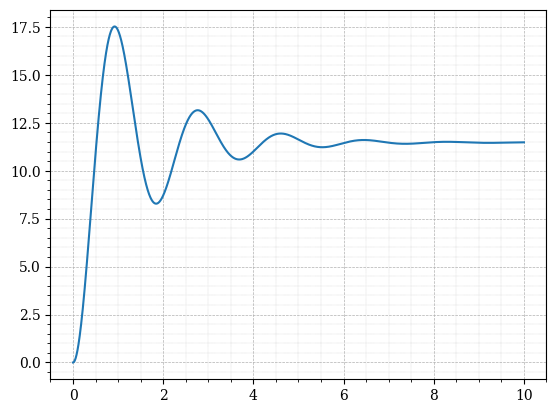

In [87]:
G = ctrl.tf([138.8], [1, 1.4, 12.1])
plant = ProcessDefinition(G, 0.00, dt=dt)

t = np.arange(0, 10, dt)
ref = np.ones_like(t)
for i in range(len(t)):
    plant.step(ref[i])

plt.plot(plant.t, plant.y)
plt.grid(which="major", linestyle="--", linewidth=0.5)
plt.minorticks_on()
plt.grid(which="minor", linestyle=":", linewidth=0.3)

In [88]:
C = 5.0


def sliding_control(e, de, y, dy):
    s = C * e + de
    u_smc = np.sign(s)
    u_n = (12.1 / 138.8) * y + ((-C + 1.4) / 138.8) * dy
    return u_smc + u_n

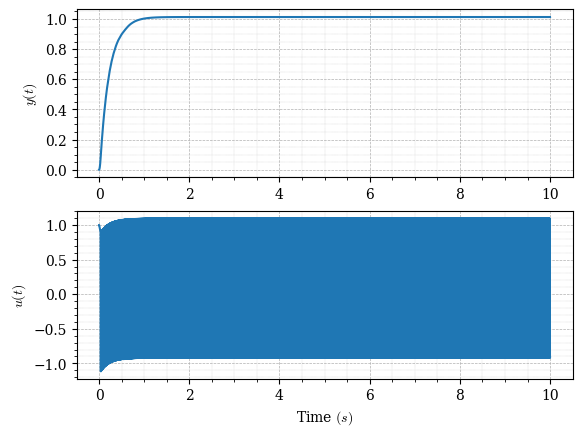

In [89]:
plant.reset()
y = 0
dy = 0
de = 0
e = 0
e_t = np.array([])
de_t = np.array([])
y_t = np.array([])
T = np.array([])
u_t = np.array([])

for i in range(len(t) - 1):
    e = 1 - y
    de = (e - e_t[-1]) / dt if e_t.size > 0 else 0
    u = sliding_control(e, de, y, dy)
    x, y, t1 = plant.step(u)
    dy = (plant.y[-1] - plant.y[-2]) / dt
    e_t = np.append(e_t, e)
    de_t = np.append(de_t, de)
    y_t = np.append(y_t, y)
    T = np.append(T, t1)
    u_t = np.append(u_t, u)

plt.subplot(2, 1, 1)
plt.plot(T, y_t)
plt.grid(which="major", linestyle="--", linewidth=0.5)
plt.minorticks_on()
plt.grid(which="minor", linestyle=":", linewidth=0.3)
plt.ylabel(r"$y(t)$")
plt.subplot(2, 1, 2)
plt.plot(T, u_t)
plt.xlabel(r"Time $(s)$")
plt.ylabel(r"$u(t)$")
plt.grid(which="major", linestyle="--", linewidth=0.5)
plt.minorticks_on()
plt.grid(which="minor", linestyle=":", linewidth=0.3)
plt.show()

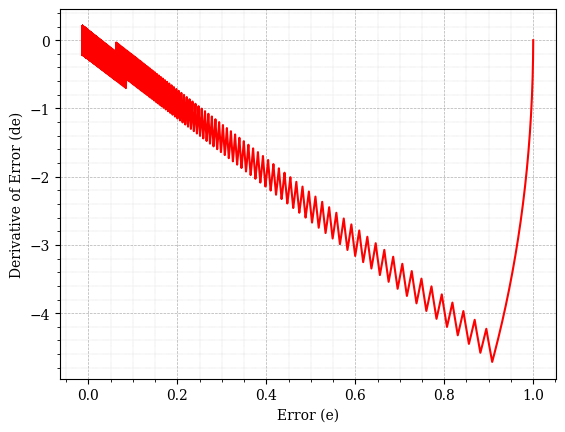

In [90]:
plt.plot(e_t, de_t, color="red")
plt.xlabel("Error (e)")
plt.ylabel("Derivative of Error (de)")
plt.minorticks_on()
plt.grid(which="major", linestyle="--", linewidth=0.5)
plt.grid(which="minor", linestyle=":", linewidth=0.3)